# CAT Bond Tutorial

In this tutorial we create and evaluate our own parametric souvereign CAT bonds. A more detailed description of how the CAT bonds are created is included in the paper "Lowering premiums and increasing investor returns by issuing multi-country CAT bonds" which is published as a preprint ([http://dx.doi.org/10.2139/ssrn.6030454]). To create the CAT bonds we will perform the following steps: 
1. Define exposure, hazard and vulnerability for each country which should be protected by a CAT bond.
2. Define the attachment (minimum payout) and exhaustion point (maximum payout = principal).
3. Devide the exposed area of each country into subareas. Each subarea will have its own payout function which uses the hazard intensity to derive the final payout based on a linear scale between the minimum and maximum payout. 
4. Calculate the expected damage for each hazard event and subarea in the simulation period. Use the expected damage per subarea per event to calibrate the payout functions per subarea. 
5. Simulate the losses of the bonds based on the payouts per hazard event. 
5. Calculate the premiums for the bond. We use three different methods: 
    - Benchmark Pricing: Premiums are set to achieve a predefined sharpe ratio.
    - Chatoro-Pricing: Based on Chatoro et al. ([https://doi.org/10.1016/j.irfa.2022.102431]) we derive the premiums based on the expected loss of our CAT bond and current market conditions. 
    - IBRD-Pricing: Based on the risk multiple (expected loss / annual premium rate) of previously issued parametric sovereign CAT bonds from the World Bank.
6. Simulate the net cash flow of the bond based on the premiums and the losses. 

<br><br>
Additionally to the single-country CAT bonds we will also create multi-country CAT bonds. For this we: 
1. Derive optimal pools using minimum risk diversification as the objective (as proposed by Ciullo et al. ([https://doi.org/10.1038/s41467-023-36539-4])). For this we set the constraint as: 
    - a fixed number of non-empty pools has to be created
    - a maximum principal is not allowed to be exceeded per multi-country CAT bond
2. Calculate the minimum principal necessary, so that the multi-country CAT bond covers all damages equally as the single-country CAT bonds.
3. Once this is done, the losses are simulated, the premiums calculated and the net cash flow is derived. 

### Import packages

In [ ]:
%load_ext autoreload
%autoreload 2
# import standard packages
import numpy as np

# import CAT bond module parts from CLIMADA-PETALS
from climada_petals.engine.cat_bonds.subareas import Subareas
from climada_petals.engine.cat_bonds.subarea_calculations import SubareaCalculations
from climada_petals.engine.cat_bonds.sng_bond_simulation import SingleCountryBondSimulation
from climada_petals.engine.cat_bonds.mlt_bond_simulation import MultiCountryBond
from climada_petals.engine.cat_bonds.premium_class import PremiumCalculations
from climada_petals.engine.cat_bonds.test.create_hazards import create_tc_hazards_for_country


# import CLIMADA core modules
from climada.entity import ImpfSetTropCyclone


## Set CAT Bond Basic Settings

We first need to set the basics for the creation of CAT bonds. This includes: 
1. Exhaustion point (Exposure_Share (set as share) or Return_Period (set as years) or None (-> set in the unit of the exposure layer)).
2. Attachment point (Exposure_Share (set as share) or Return_Period (set as years) or None (-> set in the unit of the exposure layer)).
3. Term of the bond in years.
4. Number of terms to simulate.
5. The parametric index statistic (either a float which is used to calculate percentiles of hazard intensity in each subarea or a string called 'mean' which calculates the average of the hazard intensity in each subarea).
6. Resolution for the creation of subareas. Has to be set for each country. Don't set them to small or you will end up with too many suabreas which slows down computation.
7. Define wether your CAT bond is considered peak or multi peril, has a hybrid trigger and if it is investment graded.
8. Target sharpe ratio which has to be met by setting premiums accordingly.

In [2]:
### Bond Basics ###
countries = [659, 388, 84]  # St. Kitts and Nevis, Jamaica, Belize
exhaustion_point = 0.5 # principal should be 50% of exposure 
attachment_point = 0.05 # minimum payout should be 5% of exposure
exhaustion_point_method = 'Exposure_Share' # could also be "Return_Period" or None
attachment_point_method = 'Exposure_Share' # could also be "Return_Period" or None
term = 3  # term of bond in years
num_of_terms = 200 # number of terms to simulate
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
resolution_st_kitts = 0.05 # resolution used to derive subareas for St. Kitts and Nevis
resolution_jamaica = 0.5 # resolution used to derive subareas for Jamaica
resolution_belize = 0.5 # resolution used to derive subareas for Belize

### Pricing Basics ###
peak_peril = 0 # indicator if bond is considered peak/multi peril (1) or not (0)
hybrid_trigger = 0 # indicator if bond contains a hybrid trigger (1) or not (0)
investment_graded = 0 # indicator if bond is investment graded (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio for benchmark pricing 

As you can see we will create CAT bonds for St. Kitts and Nevis, Jamaica and Belize. For each country the attachment point will equal 5% of the exposure and the exhaustion point 50%. Check the other parameters for the simulation, subarea, and pricing settings.

## Define Exposure, Hazard, and Vulnerability per Country

For each country in the list we first define exposure, hazard and vulnerability. 
1. Hazard: For each country we choose a tropical cyclone which lead to major damages and create 50 pertubated tropical cyclone tracks from it. All tracks are then assigned to varying dates.
2. Exposure: LitPop objects constructed using the countries GDP from 2020 as total asset value which is then disaggregated proportional to a combination of nightlight intensity and gridded population data. 
3. Vulnerability: Functions are taken from Eberenz et al. 2021: [https://doi.org/10.5194/nhess-21-393-2021] which have calibrated regional TC wind impact functions.

In [3]:
# Create hazard and exposure datasets for the three countries
tc_jamaica, exp_jamaica = create_tc_hazards_for_country(country_code=countries[1], storm_id="2025291N11319", bbox=(17.5, 18.75, -78.5, -76)) # create hazard and exposure for Jamaica with Tropical Cyclone Melissa
tc_kit, exp_kit = create_tc_hazards_for_country(country_code=countries[0], storm_id="2017242N16333", bbox=(17.0, 17.5, -62.9, -62.5)) # create hazard and exposure for St. Kitts and Nevis with Tropical Cyclone Irma
tc_belize, exp_belize = create_tc_hazards_for_country(country_code=countries[2], storm_id="2000273N16277", bbox=(15.5, 18.75, -89.5, -87.5)) # create hazard and exposure for Belize with Tropical Cyclone Keith

# Create vulnerability object (used for all countries)
impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()

2026-03-24 20:12:57,374 - climada.hazard.tc_tracks - INFO - Progress: 100%
2026-03-24 20:12:57,396 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.


c:\users\kai\climada\climada_python\climada\hazard\tc_tracks.py:614: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if ibtracs_ds.dims['storm'] == 0:
c:\users\kai\climada\climada_python\climada\hazard\tc_tracks.py:1511: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_one_interp_data" failed type inference due to: non-precise type pyobject
During: typing of argument at c:\users\kai\climada\climada_python\climada\hazard\tc_tracks.py (1545)

File "..\..\..\..\..\climada\climada_python\climada\hazard\tc_tracks.py", line 1545:
    def _one_interp_data(track, time_step_h, land_geom=None):
        <source elided>

            time_step = pd.tseries.frequencies.to_offset(pd.Timedelta(hours=time_step_h)).freqstr
            ^

  @staticmetho

2026-03-24 20:12:59,440 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.


<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.


2026-03-24 20:13:05,841 - climada.util.coordinates - INFO - Sampling from C:\Users\Kai\climada\data\GMT_intermediate_coast_distance_01d.tif
2026-03-24 20:13:05,858 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 7938 coastal centroids.
2026-03-24 20:13:10,460 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2026-03-24 20:13:16,112 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2026-03-24 20:13:21,152 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2026-03-24 20:13:26,649 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2026-03-24 20:13:31,160 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2026-03-24 20:13:35,060 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 70%
2026-03-24 20:13:39,978 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 82%
2026-03-24 20:13:45,510 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 94%
2026-03-24 20:13:48

## Initialise Subareas Class

Now we actually start to create a CAT bond. First, we create an instance of the Subareas class for each country which stores the subareas of the resulting CAT bonds. Note: The subarea class can also be generated with an geodataframe. Then the subareas are not calculated from the resolution but from the given geodataframe. Be sure that the given subareas cover the entire area exposed. 

2026-03-24 20:16:24,616 - climada_petals - INFO - Creating exposure perimeter polygon from exposure data.
2026-03-24 20:16:24,616 - climada_petals - INFO - Exposure total bounds: -62.85416667, 17.10416667, -62.5375, 17.4125
2026-03-24 20:16:24,634 - climada_petals - INFO - Approximate resolution: 0.009999996219511444 CRS units
2026-03-24 20:16:24,634 - climada_petals - INFO - Rasterizing exposure with width: 31, height: 30
2026-03-24 20:16:24,687 - climada_petals - INFO - Exposure perimeter polygon created.
2026-03-24 20:16:24,687 - climada_petals - INFO - Number of polygons in exposure perimeter: 2
2026-03-24 20:16:24,689 - climada_petals - INFO - Creating subareas from exposure perimeter polygon.
2026-03-24 20:16:24,689 - climada_petals - INFO - Number of polygons to process: 2
2026-03-24 20:16:24,689 - climada_petals - INFO - Processing polygon with bounds: -62.858865594780646, 17.21331666882, -62.614521506187096, 17.416405555513336
2026-03-24 20:16:24,693 - climada_petals - INFO - 

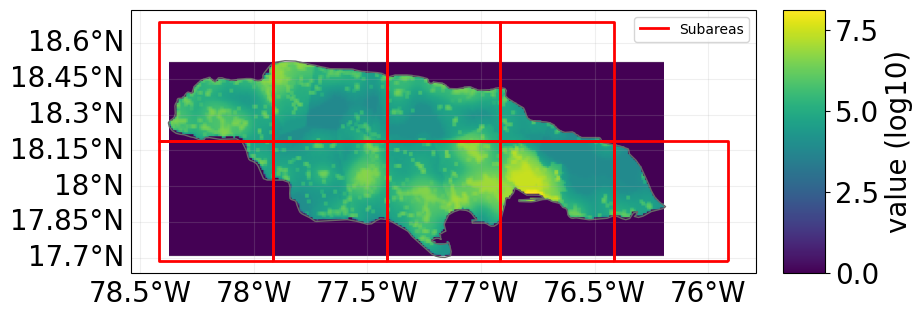

2026-03-24 20:16:55,908 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


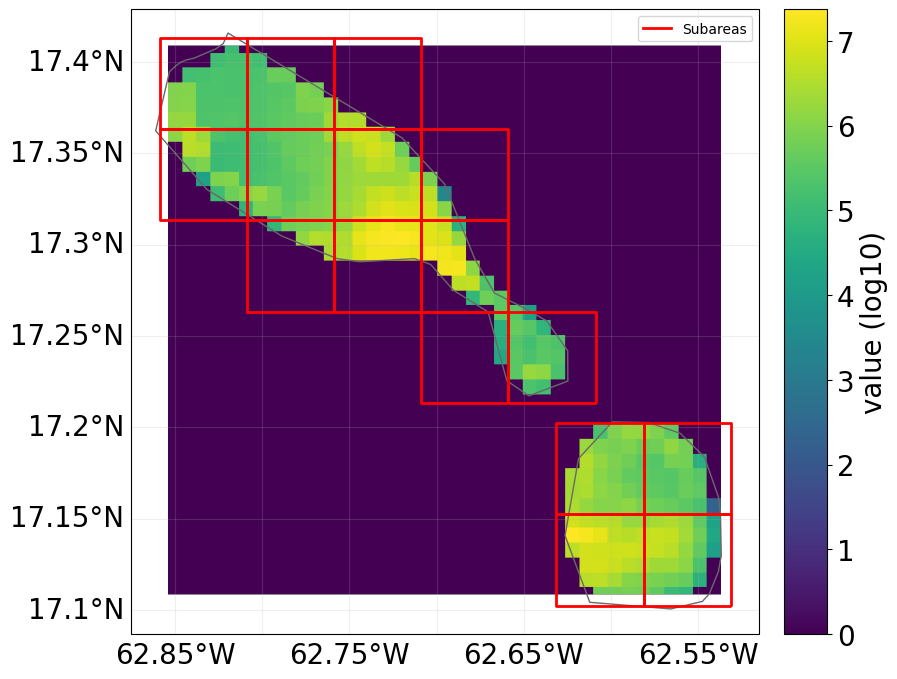

2026-03-24 20:17:30,676 - climada.util.coordinates - INFO - Raster from resolution 0.00833332999999925 to 0.00833332999999925.


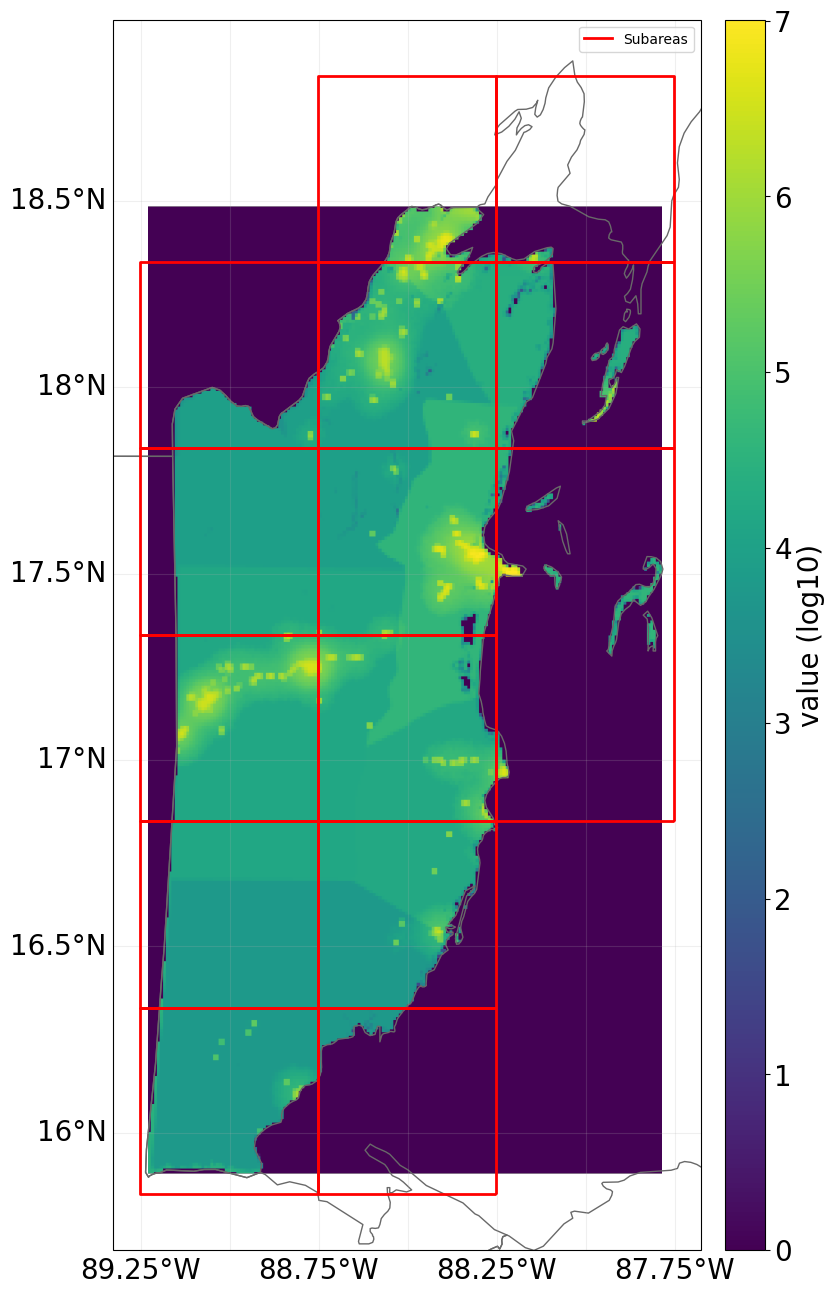

In [4]:
st_kitts_subareas = Subareas.from_resolution(tc_kit, impfset, exp_kit, resolution=resolution_st_kitts) # derive subareas for St. Kitts and Nevis
jamaica_subareas = Subareas.from_resolution(tc_jamaica, impfset, exp_jamaica, resolution=resolution_jamaica) # derive subareas for Jamaica
belize_subareas = Subareas.from_resolution(tc_belize, impfset, exp_belize, resolution=resolution_belize) # derive subareas for Belize
# Plot subareas per CAT bond
jamaica_subareas.plot()
st_kitts_subareas.plot()
belize_subareas.plot()

We can now see for each country the distribution of exposed assets as well as the subareas (red rectangles) covering the countries. Each country is divided by a different number of subareas depending on the chosen resolution and country size.

## Subarea Calculations

Based on the Subareas class and the generated subareas per CAT bond we can now derive the setups for each bond with the SubareaCalculations class. We first initialise the class and then calculate the payout vs damage dataframe. This dataframe contains for each hazard event given to the Subarea class, the damage and the payout and stores information on the hazard event year and month. 
In order to be able to create this dataframe the following computations are performed when calling the method create_pay_vs_dam(): 
1. Calculate the initial guess for the payout function optimization if it is not given with class initialization. 
2. Calculate the damage per hazard event per subarea. 
3. Derive the attachment and exhaustion point (principal) if not given as a monteary value (exhaustion/attachment_point_method == None). 
4. Optimize the payout functions per subarea. 
5. Calculate the payouts per event and subarea. 
6. Return the final payout vs damage dataframe.
Please review the logging messages for the attachment/exhaustion points and check the pay_vs_dam dataframes per CAT bond to get a feeling for the data.

In [5]:
st_kitts_sub_calc = SubareaCalculations(subareas=st_kitts_subareas, index_stat=par_index) # initialize subarea calculations for St. Kitts and Nevis
jamaica_sub_calc = SubareaCalculations(subareas=jamaica_subareas, index_stat=par_index) # initialize subarea calculations for Jamaica
belize_sub_calc = SubareaCalculations(subareas=belize_subareas, index_stat=par_index) # initialize subarea calculations for Belize
st_kitts_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for St. Kitts and Nevis
jamaica_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for Jamaica
belize_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for Belize

2026-03-24 20:18:05,202 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2026-03-24 20:18:05,202 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2026-03-24 20:18:05,214 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.
2026-03-24 20:18:05,596 - climada_petals - INFO - The attachment point and the principal of the CAT bond is: 44196111.111 and 441961111.111 [USD], respectively.
2026-03-24 20:18:06,530 - climada.entity.exposures.base - INFO - Matching 13552 exposures with 7938 centroids.
2026-03-24 20:18:06,546 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2026-03-24 20:18:06,577 - climada.engine.impact_calc - INFO - Calculating impact for 40503 assets (>0) and 51 events.
2026-03-24 20:18:06,897 - climada_petals - INFO - 

## Single-Country CAT Bond Simulation

1. Now we can simulate the losses of the bonds. For this we create an instance of the SingleCountryBondSimulation per CAT bond. Each object needs information on the term of the bond (given in years) and the number of terms to simulate. Afterwards we can call the method init_loss_simulation() per CAT bond object
2. With the information on the losses per bond (given as a dataframe containing the relative loss, month + year per loss) we can derive the annual premium rates by creating an instance of the PremiumCalculations class and then using the desired premium calculation methods. This module contains three different possibilities to derive premiums: 
    - calc_chatoro_premium() (Chatoro et al. ([https://doi.org/10.1016/j.irfa.2022.102431]) premium)
    - calc_ibrd_premium() (World Bank CAT bonds based premium)
    - calc_benchmark_premium() (Target sharpe ration premium)
3. Given the annual premium rates we can calculate the net cash flows and premium payments of each bond with init_return_simulation(). Premiums are paid at the first of each month relative to the remaining principal of the bond. The simulation is performed for one of the three derived premium rates. Premium rates can also be defined manually if desired. 
4. Inspect the metrics of the bond. 

In [6]:
### ST. KITTS AND NEVIS BOND SIMULATION ###
st_kitts_bond_sim = SingleCountryBondSimulation(subarea_calc=st_kitts_sub_calc, term=term, number_of_terms=num_of_terms) # initialize bond simulation for St. Kitts and Nevis
st_kitts_bond_sim.init_loss_simulation() # derive loss simulation for St. Kitts and Nevis
st_kitts_premiums = PremiumCalculations(bond_simulation_class=st_kitts_bond_sim) # initialize premium calculations for St. Kitts and Nevis
st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for St. Kitts and Nevis
st_kitts_premiums.calc_ibrd_premium() # derive IBRD premium for St. Kitts and Nevis
st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for St. Kitts and Nevis using target sharpe ratio
st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate) # simulate returns for St. Kitts and Nevis using Chatoro premium
display(st_kitts_bond_sim.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}%")

2026-03-24 20:18:10,401 - climada_petals - INFO - Expected Loss = 0.05427746932732757
2026-03-24 20:18:10,401 - climada_petals - INFO - Attachment Probability = 0.09
2026-03-24 20:18:10,417 - climada_petals - INFO - Using default GCIndex value of 180
2026-03-24 20:18:10,417 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-03-24 20:18:10,417 - climada_petals - INFO - Calculated Chatoro premium rate: 0.13664226860120032
2026-03-24 20:18:10,759 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.057574562106582, k=0.6461613595463143, b=1.5306263841982708
2026-03-24 20:18:10,759 - climada_petals - INFO - Calculated IBRD premium rate: 0.08968132971731153


{'Expected_annual_loss': 0.05427746932732757,
 'Annual_attachment_probability': 0.09,
 'Total_payout': 14393118391.322964,
 'Total_damages': 15075608303.027737,
 'Annual_Value_at_risk_95': 0.6392037288596383,
 'Annual_Expected_shortfall_95': 0.763924714505365,
 'Annual_Value_at_risk_99': 0.8575703156104609,
 'Annual_Expected_shortfall_99': 0.9342891061197722}

Benchmark Sharpe Ratio premium rate: 17.0%
Chatoro premium rate: 13.7%
IBRD premium rate: 9.0%


In [7]:
### JAMAICA BOND SIMULATION ###
jamaica_bond_sim = SingleCountryBondSimulation(subarea_calc=jamaica_sub_calc, term=term, number_of_terms=num_of_terms) # initialize bond simulation for Jamaica
jamaica_bond_sim.init_loss_simulation() # derive loss simulation for Jamaica
jamaica_premiums = PremiumCalculations(bond_simulation_class=jamaica_bond_sim) # initialize premium calculations for Jamaica
jamaica_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for Jamaica
jamaica_premiums.calc_ibrd_premium() # derive IBRD premium for Jamaica
jamaica_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for Jamaica using target sharpe ratio
jamaica_bond_sim.init_return_simulation(premium=jamaica_premiums.chatoro_prem_rate) # simulate returns for Jamaica using Chatoro premium
display(jamaica_bond_sim.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(jamaica_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(jamaica_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(jamaica_premiums.ibrd_prem_rate*100,1)}%")

2026-03-24 20:18:12,885 - climada_petals - INFO - Expected Loss = 0.015420185482957607
2026-03-24 20:18:12,885 - climada_petals - INFO - Attachment Probability = 0.03666666666666667
2026-03-24 20:18:12,885 - climada_petals - INFO - Using default GCIndex value of 180
2026-03-24 20:18:12,885 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-03-24 20:18:12,885 - climada_petals - INFO - Calculated Chatoro premium rate: 0.08229647141646451
2026-03-24 20:18:12,921 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.057574562106582, k=0.6461613595463143, b=1.5306263841982708
2026-03-24 20:18:12,921 - climada_petals - INFO - Calculated IBRD premium rate: 0.04670340611082372


{'Expected_annual_loss': 0.015420185482957607,
 'Annual_attachment_probability': 0.03666666666666667,
 'Total_payout': 69391825649.57356,
 'Total_damages': 89956631660.97397,
 'Annual_Value_at_risk_95': 0.0,
 'Annual_Expected_shortfall_95': 0.4205505131715711,
 'Annual_Value_at_risk_99': 0.5502399901652552,
 'Annual_Expected_shortfall_99': 0.6663076877284255}

Benchmark Sharpe Ratio premium rate: 6.2%
Chatoro premium rate: 8.2%
IBRD premium rate: 4.7%


In [8]:
### BELIZE BOND SIMULATION ###
belize_bond_sim = SingleCountryBondSimulation(subarea_calc=belize_sub_calc, term=term, number_of_terms=num_of_terms) # initialize bond simulation for Belize
belize_bond_sim.init_loss_simulation() # derive loss simulation for Belize
belize_premiums = PremiumCalculations(bond_simulation_class=belize_bond_sim) # initialize premium calculations for Belize
belize_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for Belize
belize_premiums.calc_ibrd_premium() # derive IBRD premium for Belize
belize_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for Belize using target sharpe ratio
belize_bond_sim.init_return_simulation(premium=belize_premiums.chatoro_prem_rate) # simulate returns for Belize using Chatoro premium
display(belize_bond_sim.loss_metrics)
print(f"Benchmark Sharpe Ratio premium rate: {round(belize_premiums.benchmark_prem_rate*100,1)}%")
print(f"Chatoro premium rate: {round(belize_premiums.chatoro_prem_rate*100,1)}%")
print(f"IBRD premium rate: {round(belize_premiums.ibrd_prem_rate*100,1)}%")

2026-03-24 20:18:15,139 - climada_petals - INFO - Expected Loss = 0.010743237222305892
2026-03-24 20:18:15,139 - climada_petals - INFO - Attachment Probability = 0.055
2026-03-24 20:18:15,139 - climada_petals - INFO - Using default GCIndex value of 180
2026-03-24 20:18:15,155 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-03-24 20:18:15,155 - climada_petals - INFO - Calculated Chatoro premium rate: 0.075755291579117
2026-03-24 20:18:15,172 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.057574562106582, k=0.6461613595463143, b=1.5306263841982708
2026-03-24 20:18:15,172 - climada_petals - INFO - Calculated IBRD premium rate: 0.038216984908191934


{'Expected_annual_loss': 0.010743237222305892,
 'Annual_attachment_probability': 0.055,
 'Total_payout': 6598339235.812089,
 'Total_damages': 9890053665.252056,
 'Annual_Value_at_risk_95': 0.110266821248691,
 'Annual_Expected_shortfall_95': 0.20396009929754286,
 'Annual_Value_at_risk_99': 0.23484683380300972,
 'Annual_Expected_shortfall_99': 0.24655750854703665}

Benchmark Sharpe Ratio premium rate: 3.5%
Chatoro premium rate: 7.6%
IBRD premium rate: 3.8%


## Multi-Country CAT Bond Simulation

Now that we have created 3 different single-country CAT bonds (Jamaica, St. Kitts and Nevis, Belize) we can construct a multi-country CAT bond. To do so, we first create a dictionary of the single-country CAT bonds using the country codes as dictionary keys.

In [9]:
#create dictionary of single-country bond simulation classes
sng_bonds_dic = {countries[0]: st_kitts_bond_sim,
                 countries[1]: jamaica_bond_sim,
                 countries[2]: belize_bond_sim}

For the construction of multi-country CAT bonds we have two different options: 
1. We manually choose for which countries the multi-country CAT bond should be created.
2. We derive optimal risk diverse pools, and create a CAT bond for each pool. Pools can be derived under the following constraints: 
    - The number of pools which are created is fixed
    - A defined maximum principal of a CAT bond can not be exceeded

For the first option we build a multi-country CAT bond from all three single-country CAT bonds: 
1. Initialize an instance of the multi-country CAT bond class with the term of the bond in years and the the number of terms to be simulated.
2. Calculate the minimum principal of the multi-country CAT bond which is sufficient to cover all payouts which were made during all terms of the single-country CAT bonds -> init_required_principal() 
3. Simulate the losses of the multi-country CAT bond -> init_loss_simulation()
4. Initialize a PremiumCalculations class and derive the desired premiums -> PremiumCalculations -> calc_chatoro_premium() or calc_ibrd_premium() or calc_benchmark_premium()
5. Simulate the net cash flow and premium payments of the multi-country CAT bond with the desired annual premium rate -> init_return_simulation()

In [10]:
#initialize multi-country bond simulation class
mlt_cat_bond = MultiCountryBond(country_dictionary=sng_bonds_dic, term=term,number_of_terms=num_of_terms) 
# calculate minimal required principal to achieve the same coverage as the single-country bonds
mlt_cat_bond.init_required_principal() 
mlt_cat_bond.init_loss_simulation(principal=mlt_cat_bond.requ_principal, confidence_levels=[0.95,0.99]) # derive loss simulation for multi-country bond
mlt_bond_premiums = PremiumCalculations(bond_simulation_class=mlt_cat_bond) # initialize premium calculations for multi-country bond
mlt_bond_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for multi-country bond
mlt_bond_premiums.calc_ibrd_premium() # derive IBRD premium for multi-country bond
mlt_bond_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for multi-country bond using target sharpe ratio
mlt_cat_bond.init_return_simulation(premium=mlt_bond_premiums.chatoro_prem_rate) # simulate returns for multi-country bond using Chatoro premium
display(mlt_cat_bond.loss_metrics) 
print(f"Benchmark Sharpe Ratio premium rate: {round(mlt_bond_premiums.benchmark_prem_rate*100,1)}")
print(f"Chatoro premium rate: {round(mlt_bond_premiums.chatoro_prem_rate*100,1)}")
print(f"IBRD premium rate: {round(mlt_bond_premiums.ibrd_prem_rate*100,1)}")
print(f"The required principal for the multi-country CAT bond is {round(mlt_cat_bond.requ_principal,2)} million USD.")

2026-03-24 20:18:18,214 - climada_petals - INFO - Expected Loss = 0.02063974724948574
2026-03-24 20:18:18,214 - climada_petals - INFO - Attachment Probability = 0.17166666666666666
2026-03-24 20:18:18,214 - climada_petals - INFO - Using default GCIndex value of 180
2026-03-24 20:18:18,214 - climada_petals - INFO - Using default BBSpread value of 1.6
2026-03-24 20:18:18,214 - climada_petals - INFO - Calculated Chatoro premium rate: 0.08959655050313076
2026-03-24 20:18:18,242 - climada_petals - INFO - Fitted IBRD premium parameters: a=4.057574562106582, k=0.6461613595463143, b=1.5306263841982708
2026-03-24 20:18:18,242 - climada_petals - INFO - Calculated IBRD premium rate: 0.05366006790878449


{'Expected_annual_loss': 0.02063974724948574,
 'Annual_attachment_probability': 0.17166666666666666,
 'Total_payout': 90383283276.7087,
 'Total_damages': 115075653461.52127,
 'Annual_Value_at_risk_95': 0.05192050057889184,
 'Annual_Expected_shortfall_95': 0.35168443784619324,
 'Annual_Value_at_risk_99': 0.5654407811656555,
 'Annual_Expected_shortfall_99': 0.6847149356277975}

Benchmark Sharpe Ratio premium rate: 7.0
Chatoro premium rate: 9.0
IBRD premium rate: 5.4
The required principal for the multi-country CAT bond is 7298481112.21 million USD.


### Compare the Single-Country CAT Bonds to the Multi-Country CAT Bond
Now that we have created a multi-country CAT bond, we can compare it to the previously generated single-country bonds. One very important question for the countries would be: How much coverage do I get for what price?

In [11]:
print(f"Coverage single-country bond Jamaica: {jamaica_bond_sim.loss_metrics['Total_payout'] / jamaica_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage single-country bond Belize: {belize_bond_sim.loss_metrics['Total_payout'] / belize_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage single-country bond St. Kitts and Nevis: {st_kitts_bond_sim.loss_metrics['Total_payout'] / st_kitts_bond_sim.loss_metrics['Total_damages'] * 100:.2f}%")
print(f"Coverage multi-country bond: Jamaica: {mlt_cat_bond.tot_coverage_cty[countries[1]]['coverage'] * 100:.2f}%")
print(f"Coverage multi-country bond: Belize: {mlt_cat_bond.tot_coverage_cty[countries[2]]['coverage'] * 100:.2f}%")
print(f"Coverage multi-country bond: St. Kitts and Nevis: {mlt_cat_bond.tot_coverage_cty[countries[0]]['coverage'] * 100:.2f}%")

Coverage single-country bond Jamaica: 77.14%
Coverage single-country bond Belize: 66.72%
Coverage single-country bond St. Kitts and Nevis: 95.47%
Coverage multi-country bond: Jamaica: 77.14%
Coverage multi-country bond: Belize: 66.72%
Coverage multi-country bond: St. Kitts and Nevis: 94.51%


The coverage per country does not change betweeen single- and multi-country CAT bonds. This is intended as the calculated minimum principal should cover all payouts equally as the single-country CAT bonds.

In [12]:
print(f"In the case of the multi country CAT bond the countries have to pay {((jamaica_bond_sim.return_metrics['total_premiums'] + belize_bond_sim.return_metrics['total_premiums'] + st_kitts_bond_sim.return_metrics['total_premiums']) - mlt_cat_bond.premiums['Total_premiums'].sum() * mlt_cat_bond.requ_principal):.2f} USD less premiums compared to individual CAT bonds.")
print(f"Premium savings Jamaica: {100 - ((mlt_cat_bond.premiums[countries[1]].sum() * mlt_cat_bond.requ_principal)/ jamaica_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Premium savings Belize: {100 - ((mlt_cat_bond.premiums[countries[2]].sum() * mlt_cat_bond.requ_principal)/ belize_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Premium savings St. Kitts and Nevis: {100 - ((mlt_cat_bond.premiums[countries[0]].sum() * mlt_cat_bond.requ_principal)/ st_kitts_bond_sim.return_metrics['total_premiums'] * 100):.2f}%")
print(f"Sharpe ratios multi-country bond: {round(mlt_cat_bond.sharpe_ratio, 2)} vs sharpe ratios single-country bonds: {round(st_kitts_bond_sim.return_metrics['sharpe_ratio'], 2)} (St. Kitts and Nevis), {round(jamaica_bond_sim.return_metrics['sharpe_ratio'], 2)} (Jamaica), {round(belize_bond_sim.return_metrics['sharpe_ratio'], 2)} (Belize)")

In the case of the multi country CAT bond the countries have to pay 60547213300.68 USD less premiums compared to individual CAT bonds.
Premium savings Jamaica: 19.33%
Premium savings Belize: 39.37%
Premium savings St. Kitts and Nevis: -82.90%
Sharpe ratios multi-country bond: 0.7 vs sharpe ratios single-country bonds: 0.36 (St. Kitts and Nevis), 0.71 (Jamaica), 1.34 (Belize)


Yet, premium payments are overall significantly lower. Using the implemented premium sharing mechanism where the share of the premium per country is based on the countries share of the marginal expected loss, Belize saves the most premiums (39%), while Jamaica can save around 19%. Only St. Kitts ane Nevis does not profit from pooling, as it has to pay 83% more premiums during the simulation period. However, as in total over the simulation period almost 61 billion USD in premium payments can be saved, a redistribution of premium shares could ensure that all countries are profiting. Additionally, even though premiums are reduced, the sharpe ratio of the multi-country CAT bond is within the range of the sharpe ratios of the sinlge-country CAT bonds.

### Create a CAT Bond which is Issued with Multiple Tranches

CAT bonds are often issued as tranches where each tranche covers a different level of risk. This can attract a greater number of investors as they can choose the most suitable product for themselves. In this module we implemented tranches by splitting the principal into different levels. By calling init_return_simulation_tranches() we can insert a annual premium rate per tranche and the share of the principal it covers. For example we can set two tranches, specifying that the first tranche covers 20% of the principal and the second tranche the remaining 80%. The first tranche then covers the first 20% of the principal. So all occuring losses are covered by the first tranche until the specified share of principal (20%) is depleted. Then all losses which could not be paid for by the first tranche will be paid by the second tranche.

In [13]:
mlt_cat_bond.init_return_simulation_tranches(premiums=[mlt_bond_premiums.chatoro_prem_rate,mlt_bond_premiums.chatoro_prem_rate], tranches=[0.2,0.8]) # simulate returns for multi-country bond tranches using Chatoro premium and 20%-80% tranche structure
print(f"Sharpe ratio tranche 1 (20%): {round(mlt_cat_bond.sharpe_ratio_tranches[0], 2)}")
print(f"Sharpe ratio tranche 2 (80%): {round(mlt_cat_bond.sharpe_ratio_tranches[1], 2)}")

Sharpe ratio tranche 1 (20%): 0.14
Sharpe ratio tranche 2 (80%): 0.89


By comparing the sharpe ratios of each tranche we can see that the second tranche offers a much better deal of investors. This is not surprising as we set the premiums to be equal in both tranches, but the second tranche is much more unlikely to be triggered. The first tranche will loose money as soon as the bond gets triggerd but the second tranche does not loose anything as long as the 20% of the principal, which are covered by the first tranche, are not depleted. Consequently, the second tranche will have better returns and a reduced volatility which results in a much higher sharpe ratio. 

### Construct Risk Diverse Pools for Multi-Country CAT Bond Simulation

For the second option we will use a wrapper function which first derives optimal risk diverse pools under the constraint that two pools have to be created (using the three previously calculated single-country CAT bonds). The wrapper funciton then creates a multi-country CAT bond class instance for each pool, derives the required principal, and simulates the losses. Premiums and returns can be calculated the same way as shown before or by choosing manually an annual premium rate.

In [14]:
pool_n_dic, pool_allocation_n_pool, algorithm_result_n_pool = MultiCountryBond.simulate_bond_pool_n(country_dictionary=sng_bonds_dic, 
                                                                                                    term=term, 
                                                                                                    number_of_terms=num_of_terms, 
                                                                                                    number_pools=2, 
                                                                                                    n_opt_rep=2) # simulate multiple multi-country bond pools based on a fixed number of pools optimization approach
print(f"Countries in pool 1: {pool_n_dic[1].countries}")
display(pool_n_dic[1].loss_metrics)
print("------------")
print(f"Countries in pool 2: {pool_n_dic[2].countries}")
display(pool_n_dic[2].loss_metrics)

2026-03-24 20:18:19,626 - climada_petals - INFO - Starting pooling optimization for 2 pools and 3 countries.
2026-03-24 20:18:36,255 - climada_petals - INFO - [0.8]
2026-03-24 20:18:36,255 - climada_petals - INFO - True
2026-03-24 20:18:53,334 - climada_petals - INFO - [0.8]
2026-03-24 20:18:53,336 - climada_petals - INFO - True
2026-03-24 20:18:53,343 - climada_petals - INFO - Completed pooling optimization.
{1: [659, 388], 2: [84]}
1 [659, 388]
2026-03-24 20:18:53,344 - climada_petals - INFO - Pool 1: Countries [659, 388]
2026-03-24 20:18:58,523 - climada_petals - INFO - Expected Loss = 0.019430132269220933
2026-03-24 20:18:58,523 - climada_petals - INFO - Attachment Probability = 0.12666666666666668
2026-03-24 20:18:58,532 - climada_petals - INFO - Completed loss simulation for pool 1.
2 [84]
2026-03-24 20:18:58,532 - climada_petals - INFO - Pool 2: Countries [84]
2026-03-24 20:19:01,163 - climada_petals - INFO - Expected Loss = 0.02488964718596684
2026-03-24 20:19:01,163 - climada_

{'Expected_annual_loss': 0.019430132269220933,
 'Annual_attachment_probability': 0.12666666666666668,
 'Total_payout': 83784944040.8966,
 'Total_damages': 105185599796.26924,
 'Annual_Value_at_risk_95': 0.052726917544555,
 'Annual_Expected_shortfall_95': 0.35714671756377714,
 'Annual_Value_at_risk_99': 0.5742230739772776,
 'Annual_Expected_shortfall_99': 0.6953497664668072}

------------
Countries in pool 2: [84]


{'Expected_annual_loss': 0.02488964718596684,
 'Annual_attachment_probability': 0.055,
 'Total_payout': 6598339235.812089,
 'Total_damages': 9890053665.252056,
 'Annual_Value_at_risk_95': 0.25546324821904287,
 'Annual_Expected_shortfall_95': 0.4725293509288258,
 'Annual_Value_at_risk_99': 0.5440869186023333,
 'Annual_Expected_shortfall_99': 0.5712178993911835}

As an alternative to a fixed number of pools we can set a maximum principal. The maximum principal is applied to each mulit-country CAT bond so that the sum of the principal of the single-country CAT bonds does not exceed the maximum principal per pool. We will use a wrapper function which first derives optimal risk diverse pool under the the maximum principal constraint. The wrapper funciton then creates a multi-country CAT bond class instance for each pool, derives the required principal, and simulates the losses. Premiums and returns can be calculated the same way as shown before or by choosing manually an annual premium rate.

In [15]:
pool_max_principal_dic, pool_allocation_max_prin, algorithm_result_max_prin = MultiCountryBond.simulate_bond_max_principal_pool(country_dictionary=sng_bonds_dic, 
                                                                                                                               term=term, 
                                                                                                                               number_of_terms=num_of_terms, 
                                                                                                                               maximum_principal=70000000000, 
                                                                                                                               n_opt_rep=2) # simulate multiple multi-country bond pools based on a maximum principal optimization approach
print(f"Countries in pool 1: {pool_max_principal_dic[1].countries}")
display(pool_max_principal_dic[1].loss_metrics)

2026-03-24 20:19:01,821 - climada_petals - INFO - Starting pooling optimization for pools with a maximum principal of 70000000000 and 3 countries.
2026-03-24 20:19:54,484 - climada_petals - INFO - Completed pooling optimization.
2026-03-24 20:19:54,484 - climada_petals - INFO - Pool 1: Countries [659, 388, 84]
2026-03-24 20:19:56,786 - climada_petals - INFO - Expected Loss = 0.02063974724948574
2026-03-24 20:19:56,786 - climada_petals - INFO - Attachment Probability = 0.17166666666666666
2026-03-24 20:19:56,801 - climada_petals - INFO - Completed loss simulation for pool 1.
Countries in pool 1: [659, 388, 84]


{'Expected_annual_loss': 0.02063974724948574,
 'Annual_attachment_probability': 0.17166666666666666,
 'Total_payout': 90383283276.7087,
 'Total_damages': 115075653461.52127,
 'Annual_Value_at_risk_95': 0.05192050057889184,
 'Annual_Expected_shortfall_95': 0.35168443784619324,
 'Annual_Value_at_risk_99': 0.5654407811656555,
 'Annual_Expected_shortfall_99': 0.6847149356277975}

As we can see only one pool and therefore also only one bond was created. This is because the maximum principal is higher than the sum of all three principals of the single-country CAT bonds. As all countries together in one pool achieve the highest risk diversification the countries are not splitted into different pools

In [ ]:
#####Portugal Wildfire Bond Simulation ##### -> not ready yet

#from climada_petals.entity.impact_funcs import wildfire
#wildfire.ImpfWildfire.from_default_FIRMS()
#portugal_sub_calc = SubareaCalculations(subareas=st_kitts_subareas, index_stat=par_index) # initialize subarea calculations for St. Kitts and Nevis
#portugal_sub_calc.create_pay_vs_dam(attachment_point, exhaustion_point, methods_attachment_point=attachment_point_method, methods_exhaustion_point=exhaustion_point_method) # derive payout vs damage dataframe for St. Kitts and Nevis
#### ST. KITTS AND NEVIS BOND SIMULATION ###
#st_kitts_bond_sim = SingleCountryBondSimulation(subarea_calc=st_kitts_sub_calc, term=term, number_of_terms=num_of_terms) # initialize bond simulation for St. Kitts and Nevis
#st_kitts_bond_sim.init_loss_simulation() # derive loss simulation for St. Kitts and Nevis
#st_kitts_premiums = PremiumCalculations(bond_simulation_class=st_kitts_bond_sim) # initialize premium calculations for St. Kitts and Nevis
#st_kitts_premiums.calc_chatoro_premium(peak_multi=peak_peril, investment_graded=investment_graded, hybrid_trigger=hybrid_trigger) # derive Chatoro premium for St. Kitts and Nevis
#st_kitts_premiums.calc_ibrd_premium() # derive IBRD premium for St. Kitts and Nevis
#st_kitts_premiums.calc_benchmark_premium(target_sharpe = target_sharpe) # derive benchmark premium for St. Kitts and Nevis using target sharpe ratio
#st_kitts_bond_sim.init_return_simulation(premium=st_kitts_premiums.chatoro_prem_rate) # simulate returns for St. Kitts and Nevis using Chatoro premium
#display(st_kitts_bond_sim.loss_metrics) 
#print(f"Benchmark Sharpe Ratio premium rate: {round(st_kitts_premiums.benchmark_prem_rate*100,1)}%")
#print(f"Chatoro premium rate: {round(st_kitts_premiums.chatoro_prem_rate*100,1)}%")
#print(f"IBRD premium rate: {round(st_kitts_premiums.ibrd_prem_rate*100,1)}%")